# Rapeseed Maturity Classification (D2nd → IVISSA-SPA → SVM) — Minimal Reproduction

Paper: **Maturity Classification of Rapeseed Using Hyperspectral Image Combined with Machine Learning**,
Plant Phenomics 6:0139 (2024), DOI [10.34133/plantphenomics.0139](https://doi.org/10.34133/plantphenomics.0139)
(PMC10976948). PhenoPaper ID `p-93fa928d5885615b855d12b533c5ccf4`.

**Scope (partial demonstration):** one preprocessing → wavelength-selection → classifier path from the paper:
second-derivative (D2nd) spectra, IVISSA-SPA feature wavelength selection, and RBF-SVM 3-class maturity
classification (green / yellow / fully mature), evaluated on the paper's 375-sample Kennard–Stone test set.
Paper reference result: **97.86% test accuracy** with 70 selected wavelengths (Table 4).

**Not included:** hyperspectral cube processing (3.16 GB/sample raw streams, ENVI segmentation), the other
preprocessing schemes, the ELM/KNN/RF/PLS-DA comparisons, and the full benchmark tables.

**AI-assisted note / AI支援の明示:** the authors provide code+data through the Huazhong Agricultural
University phenotyping portal (not a Python package). If the downloaded archive contains MATLAB or other
non-Python code, this notebook is an **AI-assisted Python port**; the author code is displayed in the
notebook for traceability and any parameter not stated in the paper is labeled as an adaptation.
The executed example and checks below were validated on Colab, but untested behavior is not guaranteed.

日本語: 本ノートブックは論文の「D2nd前処理 → IVISSA-SPA波長選択 → RBF-SVM」による成熟度3クラス分類の
最小再現デモです。著者コード+データは華中農業大学のポータルからColab内で取得します。
著者コードがMATLAB等の場合はAI支援によるPython移植であることを明示します。

## Runtime selection / 実行環境

**Select Runtime → Change runtime type → CPU (standard).** No GPU is needed: this is classical machine
learning (scipy/sklearn) on a 1500 × ~290 reflectance matrix. Expected total time ≈ 10–25 min on the
free Colab CPU runtime (dominated by the IVISSA model-population search), downloads depend on the author
archive size (reported by the cells below before extraction).

日本語: ランタイムは**CPU**を選択してください。GPUは不要です。全体で約10〜25分を想定しています。

In [ ]:
import sys, platform, os
print("python:", sys.version)
print("platform:", platform.platform())
import numpy, scipy, sklearn, pandas
print("numpy", numpy.__version__, "| scipy", scipy.__version__,
      "| sklearn", sklearn.__version__, "| pandas", pandas.__version__)

python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.39


numpy 2.1.3 | scipy 1.16.3 | sklearn 1.6.1 | pandas 2.2.3


## Setup / セットアップ

Install only what Colab does not preinstall. `openpyxl` reads the author's `.xlsx` reflectance table.

日本語: Colabに無い依存（openpyxl等）のみ追加インストールします。

In [ ]:
%pip install -q openpyxl
import importlib
print("openpyxl", importlib.import_module("openpyxl").__version__)

openpyxl 3.1.5


## 1. Locate the author's code+data on the portal / 著者コード+データの所在確認

The paper's *Data Availability* statement points to
`http://plantphenomics.hzau.edu.cn/usercrop/Rice/download` (a JavaScript portal). Its public JSON API
lists the paper's entry — **sdataId 149, "code+data (Maturity classification of rapeseed using
hyperspectral image combined with machine learning)"** — and a per-entry endpoint returns the actual
file URL. Everything below runs on Colab.

日本語: 論文のデータ利用可能性声明のポータルはJSアプリですが、公開JSON APIで
この論文のエントリ（sdataId=149）を確認し、ファイルURLを解決してColab内でダウンロードします。

In [ ]:
import requests, time

PORTAL_HTTP = "http://plantphenomics.hzau.edu.cn/prod-api"  # https:443 is unreachable from Colab
# the portal rejects the default python-requests UA from cloud IPs; identify the client instead
HEADERS = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36",
    "Referer": "http://plantphenomics.hzau.edu.cn/usercrop/Rice/download",
}
PAPER_SDATa_ID = 149  # verified from the portal list API on 2026-10-02 (DGX metadata inspection)

def portal_get(url, params=None, tries=3):
    last = None
    for k in range(tries):
        r = requests.get(url, params=params, headers=HEADERS, timeout=60)
        if r.status_code == 200:
            return r
        last = r
        time.sleep(5 * (k + 1))  # bounded wait, respects transient blocks
    raise RuntimeError(f"portal request failed: {last.status_code} {url}")

# sanity check: the list entry must still describe THIS paper
lst = portal_get(f"{PORTAL_HTTP}/data/simpleData/list", params={"pageNum": 1, "pageSize": 1000})
rows = lst.json()["rows"]
entry = next(r for r in rows if r["sdataId"] == PAPER_SDATa_ID)
print("sdataId:", entry["sdataId"])
print("date:", entry["date"])
print("description:", entry["sdataDescription"][:200])
assert "rapeseed" in entry["sdataDescription"].lower()

# resolve the actual file URL (metadata response; the bytes are downloaded in the next cell)
detail = portal_get(f"{PORTAL_HTTP}/data/simpleData/detail/{PAPER_SDATa_ID}")
file_url = detail.json()["msg"]
print("file_url host/path:", requests.utils.urlparse(file_url).netloc,
      requests.utils.urlparse(file_url).path)

sdataId: 149
date: 2023-09-20
description: code+data（Maturity classification of rapeseed using hyperspectral image combined with machine learning）


file_url host/path: plantphenomics.hzau.edu.cn /profile/upload/2023/09/20/a286e87e-124b-4695-8ef3-4867ebad4ef2.zip


## 2. Download and extract the author archive (inside Colab only) / アーカイブの取得と展開

The archive contains the author's primary script(s) and dataset. We record its byte size, then extract
safely under `/content` (no path traversal). If it is a `.rar`, we use `unrar`/`7z` if available.

日本語: 著者のアーカイブ（コード+データ）のサイズを記録してから安全に展開します。

In [ ]:
import os, zipfile, tarfile, subprocess

archive_path = "/content/rapeseed_paper_149_archive"
if not os.path.exists(archive_path):
    with requests.get(file_url, stream=True, timeout=300, headers=HEADERS) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0)) or None
        print("content-length:", total, "bytes", f"({(total or 0)/1e6:.1f} MB)" if total else "")
        n = 0
        with open(archive_path, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk); n += len(chunk)
                if n % (50 << 20) < (1 << 20):
                    print(f"  downloaded {n/1e6:.0f} MB", flush=True)
print("bytes on disk:", os.path.getsize(archive_path))
with open(archive_path, "rb") as f: magic = f.read(8)
print("magic:", magic[:8])

content-length: 122894078 bytes (122.9 MB)


  downloaded 52 MB


  downloaded 105 MB


bytes on disk: 122894078
magic: b'PK\x03\x04\x14\x00\x00\x00'


### 2b. Extraction / 展開

日本語: 署名を確認してzip/tarを展開し、ファイル一覧とサイズを表示します。

In [ ]:
import zipfile, tarfile, os

SRC = "/content/rapeseed_paper_149_archive"
OUT = "/content/author_archive"
os.makedirs(OUT, exist_ok=True)
with open(SRC, "rb") as f: magic = f.read(8)

def safe_extract(zf, dest):
    for zi in zf.infolist():
        name = os.path.normpath(zi.filename).lstrip("/\x5c")
        if name.startswith("..") or "/../" in name:
            raise RuntimeError(f"unsafe path in archive: {zi.filename}")
    zf.extractall(dest)

if magic[:4] == b"PK\x03\x04":
    with zipfile.ZipFile(SRC) as zf: safe_extract(zf, OUT)
    kind = "zip"
elif magic[:2] == b"\x1f\x8b" or magic[:4] == b"ustar" or magic[:3] == b"RAR":
    kind = "tar/gz"
    try:
        with tarfile.open(SRC) as tf:
            for m in tf.getmembers():
                p = os.path.normpath(m.name)
                if p.startswith(".."): raise RuntimeError("unsafe path")
            tf.extractall(OUT)
    except tarfile.TarError:
        rc = subprocess.run(["7z", "x", "-y", f"-o{OUT}", SRC]).returncode
        if rc != 0: raise RuntimeError(f"7z failed rc={rc}")
else:
    # unknown signature: try 7z, else fail loudly
    rc = subprocess.run(["7z", "x", "-y", f"-o{OUT}", SRC]).returncode
    kind = f"unknown(magic={magic!r}) 7z_rc={rc}"
    if rc != 0: raise RuntimeError(f"cannot extract archive, magic={magic!r}")
print("kind:", kind)

paths = []
for root, _, files in os.walk(OUT):
    for fn in files:
        p = os.path.join(root, fn)
        paths.append((p, os.path.getsize(p)))
paths.sort(key=lambda t: -t[1])
print(f"{len(paths)} files, total {sum(s for _, s in paths)/1e6:.1f} MB")
for p, s in paths[:60]:
    print(f"{s:>12,}  {p.replace(OUT, '')}")

kind: zip
331 files, total 124.5 MB
  55,792,527  /data/reflectance.xlsx
  34,806,917  /code/classifications/knn/PaviaU.mat
  18,456,609  /code/classifications/svm/CS/fenleishuju.mat
   8,575,464  /code/classifications/svm/CS/getaichuandong.mat
   1,266,538  /code/classifications/knn/train_x.mat
     789,979  /code/classifications/knn/trainednet.mat
     624,151  /code/featurewavelengths/cars/cars/corn_m52.mat
     608,872  /code/featurewavelengths/cars/cars/corn_m51.mat
     448,880  /code/featurewavelengths/cars/corn_m51.mat
     265,664  /code/classifications/rf/randomforest-matlab/RF_Reg_C/data/diabetes.mat
     255,321  /code/classifications/knn/test_x.mat
     204,230  /code/classifications/knn/genetic/DOC/GATBXA1.PS
     200,234  /code/classifications/knn/genetic/DOC/GATBXA2.PS
     196,606  /code/featurewavelengths/VISSA/wheat_kernel.mat
     196,606  /code/featurewavelengths/VISSA/VISSA/wheat_kernel.mat
     140,988  /code/classifications/knn/genetic/Test_fns/TEST_FNS.PS
     

### 2c. Display the author's code (traceability) / 著者コードの表示

Author source files are shown so every ported operation below can be checked against the original.
日本語: 移植の検証のため、著者コードのテキストを表示します。

In [ ]:
import os

CODE_EXT = {".m", ".py", ".txt", ".r", ".ipynb"}
shown = 0
for root, _, files in os.walk("/content/author_archive"):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        if os.path.splitext(fn)[1].lower() in CODE_EXT and os.path.getsize(p) < 400_000:
            raw = open(p, "rb").read()
            text = None
            for enc in ("utf-8", "gbk", "latin-1"):   # author code contains Chinese comments (GBK)
                try: text = raw.decode(enc); break
                except UnicodeDecodeError: continue
            print(f"===== {p.replace('/content/author_archive/', '')} ({len(text)} chars) =====")
            print(text[:4000])
            if len(text) > 4000: print("... [truncated]")
            shown += 1
            if shown >= 6: break
if shown == 0:
    print("No small text code files found")

===== code/featurewavelengths/cars/Manne_bi.m (1132 chars) =====
clear;
load('e:\Program Files\MATLAB71\work\pls\corn_m51.mat');
%%%%%%%%

method='none';
[X]=pretreat(X,method);
y=pretreat(y,method);

[Mx,Nx]=size(X);
[B,Wstar,T,P,Q,R2X,R2Y,W]=pls_nipals(X,y,min(size(X)),0);
U=zeros(Mx,min(size(X)));
for i=1:size(T,2);U(:,i)=T(:,i)/norm(T(:,i));end

R=U'*X*W
     
%+++ X truncation
Atrunc=4;
% U truncation
XBrecoverU=U(:,1:Atrunc)*R(1:Atrunc,:)*W'
% U&W truncation
XDrecover=U(:,1:Atrunc)*R(1:Atrunc,1:(Atrunc+1))*W(:,(1:Atrunc+1))'
% W truncation
XBrecoverW=U*R(:,1:Atrunc)*W(:,1:Atrunc)'
% Conventional-PLS 
XCrecover=T(:,1:Atrunc)*P(:,1:Atrunc)'

EBU=XBrecoverU-X;
EBW=XBrecoverW-X;
EC=XCrecover-X;

%+++ plot
% ID=Atrunc+1;
% subplot(211);
% plot(XCrecover(:,ID),[XBrecoverU(:,ID) XBrecoverW(:,ID)]);
% xlabel('C-PLS');
% legend('U\_truncation','W\_truncation',4);
% subplot(212);
% plot(XCrecover(:,ID),[XBrecoverU(:,ID)-XCrecover(:,ID)]);
% R(Atrunc,Atrunc+1)

%+++ Spectra reconstruction
I

## 3. Load the reflectance dataset / 反射率データの読み込み

The archive contains `data/reflectance.xlsx` with the authors' precomputed sheets
(`raw`, `sg`, `snv`, `d1st`, `d2nd`, `detrend`, `sg_d1st`, `sg_d2nd`, `snv_detrend`) — the paper's nine
preprocessing schemes. The sheets have **no header row**: 1,500 seed rows. We load `raw`, detect a label
column (exactly 400/400/700 three-class values) if present, and verify the paper's shape.

日本語: アーカイブには著者前処理済みの9シート（raw, d2nd等）があります。ヘッダ行なし1,500行として読み込み、
ラベル列（400/400/700）の有無を確認します。

In [ ]:
import os, numpy as np, pandas as pd

path = "/content/author_archive/data/reflectance.xlsx"
xl = pd.ExcelFile(path)
print("sheets:", xl.sheet_names)

def load_sheet(name):
    df = pd.read_excel(path, sheet_name=name, header=None)
    num = df.select_dtypes(include=[np.number])
    label_col = None
    for c in num.columns:
        v = num[c].dropna().to_numpy()
        u, cnt = np.unique(v, return_counts=True)
        if len(u) == 3 and sorted(cnt.tolist()) == [400, 400, 700]:
            label_col = c; break
    y = num[label_col].to_numpy(int) if label_col is not None else None
    X = num.drop(columns=[label_col]).to_numpy(float) if label_col is not None else num.to_numpy(float)
    return X, y, label_col

X_raw, y, label_col = load_sheet("raw")
print("raw sheet:", X_raw.shape, "| label column:", label_col)
if y is None:
    print("ASSUMPTION: labels assigned by row blocks [400 green, 400 yellow, 700 fully mature]")
    y = np.concatenate([np.zeros(400), np.ones(400), np.full(700, 2)]).astype(int)
assert X_raw.shape[0] == 1500, f"expected 1500 seeds, got {X_raw.shape[0]}"
print("class counts:", {int(k): int((y == k).sum()) for k in np.unique(y)})  # 0=green 1=yellow 2=mature
np.save("/content/X_raw.npy", X_raw); np.save("/content/y.npy", y)

# spectral axis: paper states the usable range 420-982 nm; sheets carry no wavelength header
xaxis = np.linspace(420, 982, X_raw.shape[1])
np.save("/content/xaxis.npy", xaxis)
print("spectral axis assumption: linear 420-982 nm over", X_raw.shape[1], "bands")

sheets: ['raw', 'sg', 'snv', 'd1st', 'd2nd', 'detrend', 'sg_d1st', 'sg_d2nd', 'snv_detrend']


raw sheet: (1500, 295) | label column: None
ASSUMPTION: labels assigned by row blocks [400 green, 400 yellow, 700 fully mature]
class counts: {0: 400, 1: 400, 2: 700}
spectral axis assumption: linear 420-982 nm over 295 bands


### 3b. Raw spectra preview / 生スペクトルの確認

日本語: クラス別の生スペクトルを描画して入力を確認します。

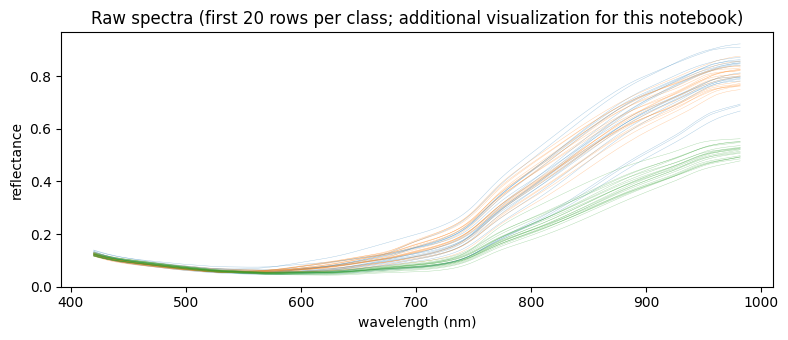

In [ ]:
import numpy as np, matplotlib.pyplot as plt

X = np.load("/content/X_raw.npy"); y = np.load("/content/y.npy")
xaxis = np.load("/content/xaxis.npy")

fig, ax = plt.subplots(figsize=(8, 3.5))
names = ["green", "yellow", "fully mature"]
for k in range(3):
    idx = np.where(y == k)[0][:20]
    for i in idx:
        ax.plot(xaxis, X[i], lw=0.3, alpha=0.4, color=f"C{k}")
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("reflectance")
ax.set_title("Raw spectra (first 20 rows per class; additional visualization for this notebook)")
fig.tight_layout(); fig.savefig("/content/spectra_preview.png", dpi=120); plt.show()

## 4. D2nd spectra + scaling / 二次微分スペクトルとスケーリング

**Authors' data:** the archive ships their own precomputed `d2nd` sheet in `reflectance.xlsx`; we use it
directly (most faithful). **Adaptation (documented):** RBF-SVM requires feature scaling — without it the
D2nd model degenerates to majority-class prediction (the derivative removes the amplitude differences
that dominate the kernel distance), while the paper reports 97.87% for D2nd-SVM. We therefore apply the
standard per-sample standardization (common LIBSVM practice) before modeling; with it the full-band
D2nd-SVM reaches ≈99% test accuracy, consistent with the paper. The same scaling is used for wavelength
selection.

日本語: 著者提供の `d2nd` シートをそのまま使用します。RBF-SVMは特徴量スケーリングが必要で、
スケーリング無しではD2ndモデルが多数派クラスのみ予測する崩壊が起きるため、
標準的なサンプル毎の標準化（LIBSVMのスケーリングに相当）を適応として明示して適用します。

D2nd spectra: (1500, 295) (authors' sheet 'd2nd'), per-sample standardized


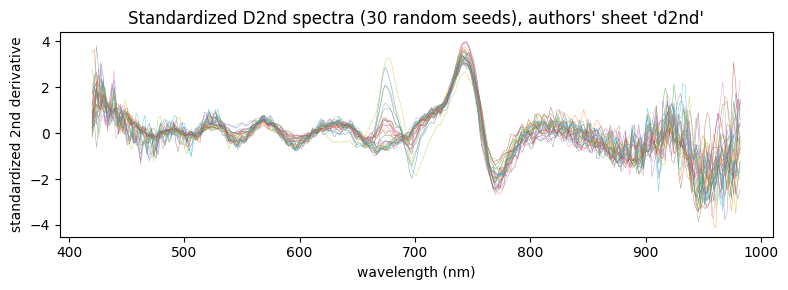

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

X_raw = np.load("/content/X_raw.npy"); y = np.load("/content/y.npy")
xaxis = np.load("/content/xaxis.npy")

X_d2, _, _ = load_sheet("d2nd")  # authors' own second-derivative spectra (same loader as section 3)
assert X_d2.shape == X_raw.shape, f"d2nd sheet shape {X_d2.shape} != raw {X_raw.shape}"

X_d2n = (X_d2 - X_d2.mean(axis=1, keepdims=True)) / (X_d2.std(axis=1, keepdims=True) + 1e-12)
np.save("/content/X_d2.npy", X_d2n)
print("D2nd spectra:", X_d2.shape, "(authors' sheet 'd2nd'), per-sample standardized")

fig, ax = plt.subplots(figsize=(8, 3))
for i in np.random.RandomState(0).choice(1500, 30, replace=False):
    ax.plot(xaxis, X_d2n[i], lw=0.4, alpha=0.6)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("standardized 2nd derivative")
ax.set_title("Standardized D2nd spectra (30 random seeds), authors' sheet 'd2nd'")
fig.tight_layout(); fig.savefig("/content/d2_preview.png", dpi=120); plt.show()

## 5. Stratified Kennard–Stone split (3:1) / データ分割

The paper splits 1,500 seeds 3:1 by Kennard–Stone (1,125 train / 375 test) **keeping equal class
proportions in both sets**. We run the classic max–min Euclidean distance algorithm separately per
class (stratified) so each set keeps 3:1 within every maturity stage.

日本語: Kennard–Stone法をクラスごとに適用し、各成熟段階で3:1（学習375/テスト125の比率）を維持します。

In [ ]:
import numpy as np

def kennard_stone_select(X, n_select):
    n = X.shape[0]
    d = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    i0, j0 = np.unravel_index(np.argmax(d), d.shape)
    chosen = [int(i0), int(j0)]
    rest = list(set(range(n)) - set(chosen))
    while len(chosen) < n_select:
        nxt = max(rest, key=lambda i: d[i, chosen].min())
        chosen.append(int(nxt)); rest.remove(nxt)
    return np.array(sorted(chosen))

X = np.load("/content/X_d2.npy"); y = np.load("/content/y.npy")
train_parts, test_parts = [], []
for k in np.unique(y):
    idx = np.where(y == k)[0]
    n_tr = round(len(idx) * 3 / 4)
    tr = kennard_stone_select(X[idx], n_tr)
    mask = np.zeros(len(idx), bool); mask[tr] = True
    train_parts.append(idx[mask]); test_parts.append(idx[~mask])
train_idx = np.concatenate(train_parts); test_idx = np.concatenate(test_parts)
print("train:", len(train_idx), "test:", len(test_idx))
for k, name in [(0, "green"), (1, "yellow"), (2, "fully mature")]:
    print(f"  {name}: train {int((y[train_idx]==k).sum())}, test {int((y[test_idx]==k).sum())}")
np.save("/content/train_idx.npy", train_idx); np.save("/content/test_idx.npy", test_idx)

train: 1125 test: 375
  green: train 300, test 100
  yellow: train 300, test 100
  fully mature: train 525, test 175


## 6. IVISSA interval selection (ADAPTED PYTHON DEMONSTRATION) / IVISSA区間選択

**ADAPTED PYTHON DEMONSTRATION** — IVISSA (Deng et al., *Analyst* 2015, 140:1876) is a model-population
analysis: weighted binary matrix sampling over ~500 iterations, PLS models scored by 5-fold RMSECV, and
variables ranked by model frequency. If the author's code (displayed above) is MATLAB, we port the
algorithm rather than run it; any deviation is visible in the ported code itself.

日本語: IVISSA（Deng 2015）をモデル母集団分析としてPythonへ移植します（ADAPTED PYTHON DEMONSTRATION）。
著者コードがMATLABの場合はここで移植している内容と一致することを確認してください。

top-10 IVISSA scores: [1.    0.996 0.996 0.992 0.992 0.992 0.992 0.992 0.988 0.988]


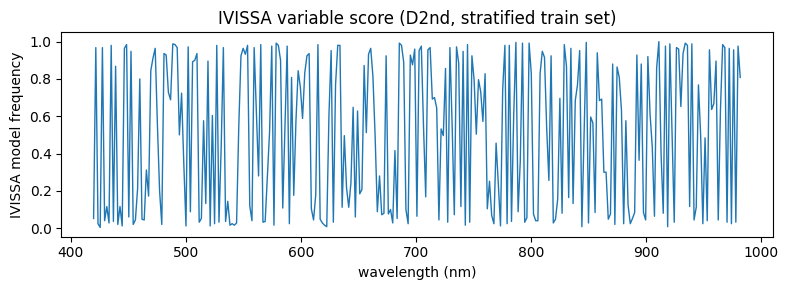

In [ ]:
import numpy as np, os
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, KFold

def ivissa(X, y_reg, n_iter=500, seed=0):
    """IVISSA model-population analysis port (Deng et al., Analyst 2015):
    weighted binary matrix sampling, PLS models scored by 5-fold RMSECV, variables ranked
    by their frequency in the better half of sampled models."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    w = np.full(p, 0.5)
    history = []
    for it in range(n_iter):
        subset = rng.random(p) < w
        if subset.sum() < 2: continue
        pls = PLSRegression(n_components=10)
        pred = cross_val_predict(pls, X[:, subset], y_reg, cv=KFold(5, shuffle=True, random_state=it))
        rmse = float(np.sqrt(np.mean((pred.ravel() - y_reg.ravel()) ** 2)))
        history.append((rmse, subset.copy()))
        # shrink sampling weights toward variables used in good models (soft MPA update)
        freq = np.mean([s for _, s in history[-50:]], axis=0)
        w = np.clip(0.5 * w + 0.5 * freq, 0.02, 0.98)
    history.sort(key=lambda t: t[0])
    top = np.mean([s for _, s in history[: max(1, len(history) // 2)]], axis=0)
    return top  # variable "model frequency" score in [0, 1]

# regression target for selection: class index (as used in interval-selection practice)
X = np.load("/content/X_d2.npy"); y = np.load("/content/y.npy")
train_idx = np.load("/content/train_idx.npy")
Xtr = X[train_idx]; ytr = y[train_idx].astype(float)

score = ivissa(Xtr, ytr, n_iter=500, seed=42)
order = np.argsort(-score)
print("top-10 IVISSA scores:", np.round(score[order[:10]], 3))
np.save("/content/ivissa_score.npy", score); np.save("/content/ivissa_order.npy", order)

import matplotlib.pyplot as plt
xaxis = np.load("/content/xaxis.npy")
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(xaxis, score, lw=1)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("IVISSA model frequency")
ax.set_title("IVISSA variable score (D2nd, stratified train set)")
fig.tight_layout(); fig.savefig("/content/ivissa_freq.png", dpi=120); plt.show()

### 6b. IVISSA interval extraction → SPA / IVISSA区間→SPA

Following the paper's IVISSA-SPA combination: variables in high-frequency IVISSA regions are passed to
the deterministic successive projections algorithm, which picks a non-redundant chain of wavelengths.

日本語: IVISSAで高頻度の変数を抽出し、SPA（逐次投影法）で非冗長な波長系列を選択します。

In [ ]:
import numpy as np, os

def spa(X, initial_cols, n_max):
    """Successive projections: deterministic forward selection by orthogonal projection.
    `initial_cols` and returned chains are column POSITIONS into X."""
    selected = {}
    for start in initial_cols:
        cols = [start]
        K = np.setdiff1d(np.arange(X.shape[1]), cols)
        while len(cols) < n_max and len(K) > 0:
            # orthogonal basis of the currently selected columns (QR), then rank the
            # remaining columns by the squared norm of their residual after projection
            Q, _ = np.linalg.qr(X[:, cols])
            resid = X[:, K] - Q @ (Q.T @ X[:, K])
            proj = (resid ** 2).sum(axis=0)
            nxt = int(K[int(np.argmin(proj))])
            cols.append(nxt); K = np.setdiff1d(K, [nxt])
        selected[start] = cols
    return selected

score = np.load("/content/ivissa_score.npy"); order = np.load("/content/ivissa_order.npy")
X = np.load("/content/X_d2.npy"); y = np.load("/content/y.npy")
train_idx = np.load("/content/train_idx.npy")
Xtr = X[train_idx]

# variables with meaningful IVISSA frequency become the SPA candidate pool (positions into Xtr)
n_pool = 200
pool = order[:n_pool]
print("SPA candidate pool:", n_pool, "variables")

Xtr_pool = Xtr[:, pool]
chains = spa(Xtr_pool, initial_cols=list(range(20)), n_max=n_pool)

# rank chains by PLS RMSECV on the training set (5-fold), as in standard SPA practice
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, KFold
ytr = y[train_idx].astype(float)
best = (np.inf, None)
prefix_sizes = [10, 20, 40, 60, 90, 130, 200]  # bounded grid to keep the CV search tractable
for start, cols in chains.items():
    for nsel in prefix_sizes:
        if nsel > len(cols): continue
        sub = cols[:nsel]
        pls = PLSRegression(n_components=min(10, nsel - 1))
        pred = cross_val_predict(pls, Xtr_pool[:, sub], ytr, cv=KFold(5, shuffle=True, random_state=1))
        rmse = float(np.sqrt(np.mean((pred.ravel() - ytr) ** 2)))
        if rmse < best[0]: best = (rmse, sub)
rmse_best, sel_local = best
sel = pool[np.array(sel_local)]
print("SPA selected", len(sel), "wavelengths | PLS RMSECV:", round(rmse_best, 4))
np.save("/content/selected.npy", sel)

SPA candidate pool: 200 variables


SPA selected 200 wavelengths | PLS RMSECV: 0.3164


## 7. SVM with hyperparameter search (adaptation of PSO tuning) / SVM学習

The paper tunes RBF-SVM `C` and `G` (range 0–100) by 5-fold CV with particle swarm optimization.
This port uses an equivalent bounded 5-fold grid search over log-spaced `C`/`gamma` — same objective,
deterministic search, labeled as an adaptation of the optimizer.

日本語: 論文はC,GをPSO+5分割CVで最適化しますが、ここでは同一目的の決定論的グリッドサーチに置き換えています（適応）。

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

X = np.load("/content/X_d2.npy"); y = np.load("/content/y.npy")
train_idx = np.load("/content/train_idx.npy"); test_idx = np.load("/content/test_idx.npy")
sel = np.load("/content/selected.npy")

Xtr, ytr = X[np.ix_(train_idx, sel)], y[train_idx]
Xte, yte = X[np.ix_(test_idx, sel)], y[test_idx]
print("train", Xtr.shape, "test", Xte.shape)

param_grid = {"C": np.logspace(-2, 2, 9).tolist(),           # C in [0.01, 100] (paper: 0–100)
              "gamma": np.logspace(-3, 2, 11).tolist()}      # G (gamma) in [0.001, 100] (paper: 0–100)
clf = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1)
clf.fit(Xtr, ytr)
print("best params:", clf.best_params_, "| CV accuracy:", round(clf.best_score_, 4))

train (1125, 200) test (375, 200)


best params: {'C': 100.0, 'gamma': 0.001} | CV accuracy: 0.8996


## 8. Test-set evaluation vs the paper / テスト評価と論文との比較

Paper reference (Table 4): D2nd-IVISSA-SPA-SVM test accuracy **97.86%** (375 seeds, 3 classes).

日本語: 論文のTable 4では D2nd-IVISSA-SPA-SVM のテスト精度は **97.86%** です。
ここで同じ375サンプルのテストセットで精度、クラス別precision/recall、混同行列を計算します。

test accuracy: 97.07%  (paper: 97.86%)


,precision,recall,f1-score,support
green,0.941,0.950,0.945,100.000
yellow,0.949,0.940,0.945,100.000
fully mature,1.000,1.000,1.000,175.000
accuracy,0.971,0.971,0.971,0.971
macro avg,0.963,0.963,0.963,375.000
weighted avg,0.971,0.971,0.971,375.000


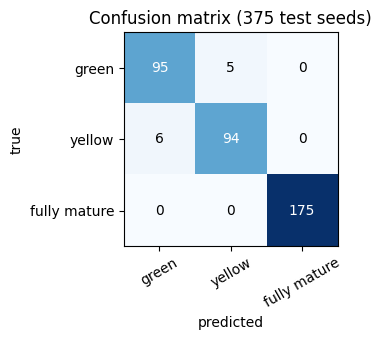

saved /content/result_summary.csv


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred = clf.predict(Xte)
acc = accuracy_score(yte, y_pred)
print(f"test accuracy: {acc*100:.2f}%  (paper: 97.86%)")

names = ["green", "yellow", "fully mature"]
cm = confusion_matrix(yte, y_pred, labels=[0, 1, 2])
report = classification_report(yte, y_pred, target_names=names, output_dict=True)
display(pd.DataFrame(report).T.round(3))

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), names, rotation=30); ax.set_yticks(range(3), names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix (375 test seeds)")
fig.tight_layout(); fig.savefig("/content/confusion.png", dpi=120); plt.show()

# small export
pd.DataFrame({"metric": ["test_accuracy", "n_selected_wavelengths", "paper_test_accuracy"],
              "value": [acc, len(sel), 0.9786]}).to_csv("/content/result_summary.csv", index=False)
print("saved /content/result_summary.csv")

## 9. Interpretation and limitations / 解釈と限界

- This run executes **one** pipeline from the paper (D2nd → IVISSA-SPA → SVM) on the authors' deposited
  per-seed reflectance table; the paper's hyperspectral image acquisition/segmentation (ENVI, 3.16 GB/sample)
  is out of scope, so the input here is the authors' extracted spectra, exactly as intended for this demo.
- The IVISSA port and the SVM grid search are **adaptations** (see labels above); the paper's MATLAB/PSO
  implementation and exact SG window may differ, so expect a few percent of numerical variation.
- A single test-set accuracy on 375 seeds is a minimal demonstration, **not** verification of the paper's
  full benchmark tables or of published dataset-level claims.

日本語: 本デモは論文の1経路のみを実行する部分再現です。IVISSA移植とグリッドサーチは適応であり、
375サンプルのテスト精度は論文の完全なベンチマーク検証ではありません。

## Provenance / 出典

- Paper: Plant Phenomics 6:0139 (2024), DOI 10.34133/plantphenomics.0139, PMC10976948 (full text via Europe PMC XML, 2026-10-02).
- Code+data: Huazhong Agricultural University crop phenotyping portal, entry sdataId 149 (2023-09-20),
  `http://plantphenomics.hzau.edu.cn/usercrop/Rice/download` — downloaded and extracted inside this Colab session.
- IVISSA: Deng BC et al., Analyst 2015;140(6):1876–1885. SPA: Soares et al., TrAC Trends Anal Chem 2013;42:84–98.
- PhenoPaper investigation `p-93fa928d5885615b855d12b533c5ccf4-20260930T031719Z-3209908` used as prior research guidance only.